# Implementation of a Deep Asset Liability Management Environment

In [1]:
import os
import sys
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../..')))

from environment.config import markov_config
from environment.bond import Bond
from environment.env import DeepALMEnv
from models.utils import print_bond_universe, plot_learning_curve, plot_final_wealth
from models.source.ppo import evaluate_ppo_agent, evaluate_ppo_alm
from models.DirichletPolicy import DirichletActorCriticPolicy
from typing import Callable

In [2]:
TRAINING = True
DIRICHLET = False

In [3]:
if DIRICHLET:
    # Create logging directory
    log_dir = "tmp_log/PPO10/Dirichlet"
    os.makedirs(log_dir, exist_ok=True)
else:
    log_dir = "tmp_log/PPO10/Gaussian"
    os.makedirs(log_dir, exist_ok=True)

## Gym Wrapper for SB3 compatibility

In [4]:
# Create and display bond universe
bonds = [Bond(**cfg) for cfg in markov_config["bond_configs"]]
K = len(bonds)
print_bond_universe(bonds)

# Initialize Training Environment
env = DummyVecEnv([lambda: Monitor(
    DeepALMEnv(markov_config=markov_config, seed=10, use_dirichlet=DIRICHLET), 
    filename=os.path.join(log_dir, "monitor.csv"), 
    info_keywords=('nav',)
)])

-----------------------------------------------
| Bond Type            | Maturity (Months)    |
-----------------------------------------------
| 1M_Bill              | 1                    |
| 3M_ZeroCoupon        | 3                    |
| 6M_ZeroCoupon        | 6                    |
| 12M_6Months          | 12                   |
| 24M_6Months          | 24                   |
-----------------------------------------------


In [5]:
# Linear Schedule Helper for Learning Rate
def linear_schedule(initial_value: float) -> Callable[[float], float]:
    """
    Linear learning rate schedule.
    :param initial_value: Initial learning rate.
    :return: schedule that computes current rate depending on remaining progress
    """
    def func(progress_remaining: float) -> float:
        # progress_remaining starts at 1.0 and goes to 0.0
        return progress_remaining * initial_value
    return func

model = PPO(
    policy=DirichletActorCriticPolicy if DIRICHLET else "MultiInputPolicy",
    env=env,

    learning_rate=0.001,
    n_steps=512,
    batch_size=128,
    n_epochs=10,
    clip_range=0.1,
    
    gamma=1.0,         # No discounting: because we care about terminal utility
    gae_lambda=0.95,
    

    use_sde=False,
    ent_coef=0.001,

    policy_kwargs=dict(
        net_arch=dict(pi=[256, 256], vf=[256, 256]),
        log_std_init=-2,
    ),

    verbose=1,
    device="auto"
)

Using cpu device


In [6]:
if TRAINING:
    print("Starting PPO training...")
    model.learn(total_timesteps=600_000, log_interval=10)
    print("Training completed.")
    model.save("saved_models/ppo_alm.zip")
else:
    print("Loading pre-trained model...")
    model = PPO.load("saved_models/ppo_alm.zip")


Starting PPO training...
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 7.08       |
|    ep_rew_mean          | -1.05      |
| time/                   |            |
|    fps                  | 181        |
|    iterations           | 10         |
|    time_elapsed         | 28         |
|    total_timesteps      | 5120       |
| train/                  |            |
|    approx_kl            | 0.18926698 |
|    clip_fraction        | 0.8        |
|    clip_range           | 0.1        |
|    entropy_loss         | 3.07       |
|    explained_variance   | -0.0822    |
|    learning_rate        | 0.001      |
|    loss                 | 0.0336     |
|    n_updates            | 90         |
|    policy_gradient_loss | 0.0545     |
|    std                  | 0.146      |
|    value_loss           | 0.00804    |
----------------------------------------
----------------------------------------
| rollout/                |     

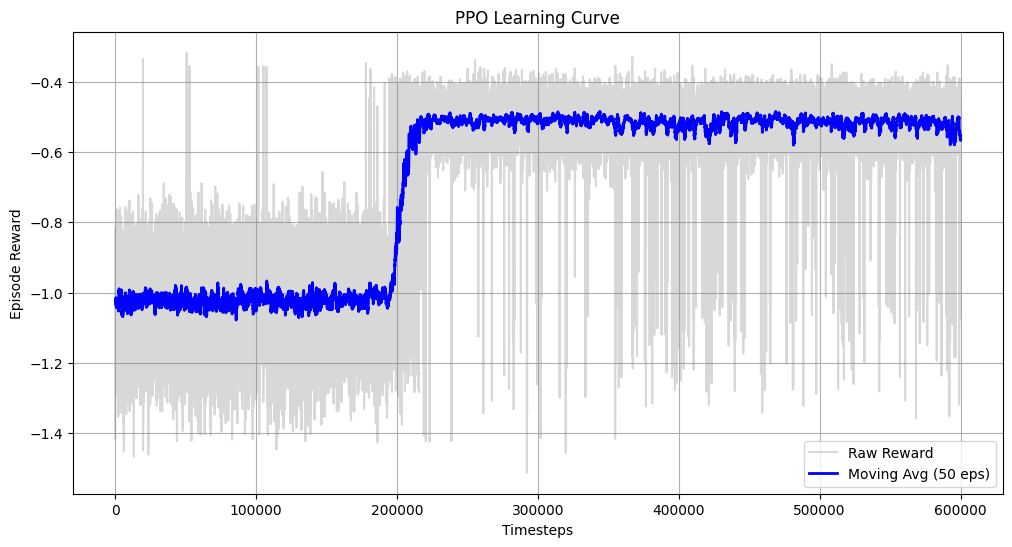

In [7]:
if TRAINING:
    plot_learning_curve(log_dir, "PPO Learning Curve")

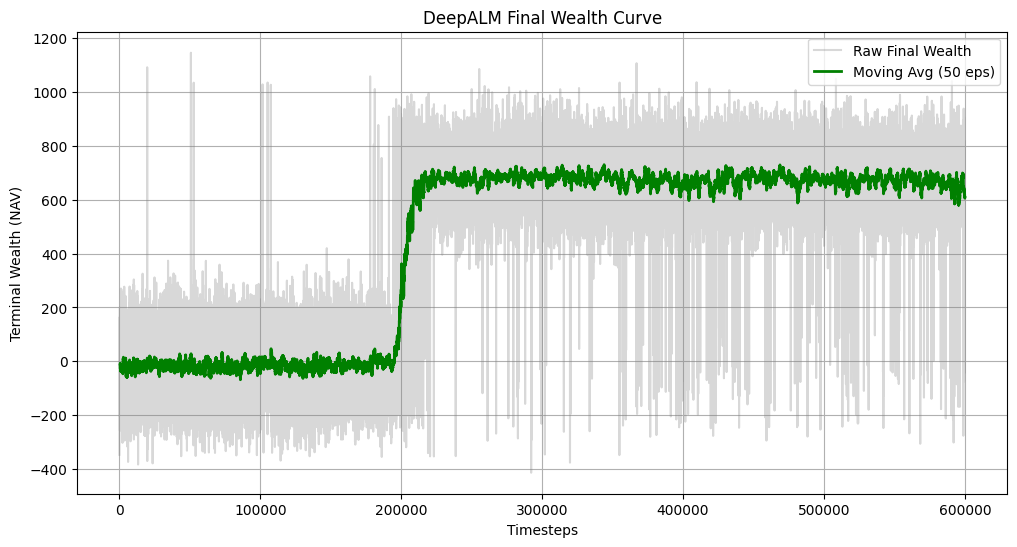

In [8]:
if TRAINING:
    plot_final_wealth(log_dir)

In [9]:
# Single-episode evaluation
print("\nRunning Single Episode Deep Dive")
evaluate_ppo_agent(model, markov_config, K, seed=0, verbose=True);


Running Single Episode Deep Dive
Month 1:
1M Bond Lots: None
3M Bond Lots: None
6M Bond Lots: None
12M Bond Lots: None
24M Bond Lots: None
  Current Market Yields
    1M: 1.96%
    3M: 2.54%
    6M: 2.90%
    12M: 3.13%
    24M: 3.29%
  Cash Before Action: 2000.00
  Inflows: 0.00  |  Liability Due: 59.29  |  Next Liability: 39.29
  Cash After Action: 828.17
  LCR: 23.6013  |  Utility: -0.53
  ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  | Bond Type       |        1M        2M        3M        4M        5M        6M        7M        8M        9M       10M       11M       12M       13M       14M       15M       16M       17M       18M       19M       20M       21M       22M       23M       24M |      Total |
  -----------------------------------------------

In [ ]:
# Out-of-sample statistical evaluation
print("\nRunning Out-Of-Sample Evaluation")
eval_metrics, eval_raw_results = evaluate_ppo_alm(
    model=model,                       
    markov_config=markov_config,       
    eval_episodes=2000,                
    seed_offset=10_000_000,               
    verbose_first_episode=True         
)


Running Out-Of-Sample Evaluation

--- Starting PPO Evaluation ---
Ep 0 | Month  1 | NAV:   725.60 | LCR: 15.64 | Step Reward: 0.00
Ep 0 | Month  2 | NAV:   693.25 | LCR: 16.75 | Step Reward: 0.00
Ep 0 | Month  3 | NAV:   693.26 | LCR: 26.36 | Step Reward: 0.00
Ep 0 | Month  4 | NAV:   693.14 | LCR: 18.32 | Step Reward: 0.00
Ep 0 | Month  5 | NAV:   715.79 | LCR:  8.85 | Step Reward: 0.00
Ep 0 | Month  6 | NAV:   705.56 | LCR: 14.38 | Step Reward: 0.00
Ep 0 | Month  7 | NAV:   723.37 | LCR: 10.29 | Step Reward: 0.00
Ep 0 | Month  8 | NAV:   734.55 | LCR:  6.73 | Step Reward: 0.00
Ep 0 | Month  9 | NAV:   735.72 | LCR:  7.94 | Step Reward: 0.00
Ep 0 | Month 10 | NAV:   737.10 | LCR:  7.88 | Step Reward: 0.00
Ep 0 | Month 11 | NAV:   731.49 | LCR:  7.37 | Step Reward: 0.00
Ep 0 | Month 12 | NAV:   735.76 | LCR:  8.27 | Step Reward: 0.00
Ep 0 | Month 13 | NAV:   737.12 | LCR:  8.89 | Step Reward: 0.00
Ep 0 | Month 14 | NAV:   751.45 | LCR:  6.52 | Step Reward: 0.00
Ep 0 | Month 15 | NAV: 

In [ ]:
# Out-of-sample statistical evaluation
print("\nRunning Out-Of-Sample Evaluation")
eval_metrics, eval_raw_results = evaluate_ppo_alm(
    model=model,                       
    markov_config=markov_config,       
    eval_episodes=100_000,                
    seed_offset=100_000_000,               
    verbose_first_episode=True         
)


Running Out-Of-Sample Evaluation

--- Starting PPO Evaluation ---
Ep 0 | Month  1 | NAV:   726.63 | LCR: 15.64 | Step Reward: 0.00
Ep 0 | Month  2 | NAV:   738.65 | LCR:  7.86 | Step Reward: 0.00
Ep 0 | Month  3 | NAV:   727.08 | LCR: 14.70 | Step Reward: 0.00
Ep 0 | Month  4 | NAV:   727.61 | LCR: 10.43 | Step Reward: 0.00
Ep 0 | Month  5 | NAV:   721.61 | LCR:  7.26 | Step Reward: 0.00
Ep 0 | Month  6 | NAV:   718.04 | LCR: 10.87 | Step Reward: 0.00
Ep 0 | Month  7 | NAV:   718.86 | LCR:  9.59 | Step Reward: 0.00
Ep 0 | Month  8 | NAV:   709.23 | LCR: 10.05 | Step Reward: 0.00
Ep 0 | Month  9 | NAV:   703.37 | LCR: 15.39 | Step Reward: 0.00
Ep 0 | Month 10 | NAV:   714.10 | LCR: 10.75 | Step Reward: 0.00
Ep 0 | Month 11 | NAV:   741.51 | LCR:  5.47 | Step Reward: 0.00
Ep 0 | Month 12 | NAV:   726.42 | LCR: 10.20 | Step Reward: 0.00
Ep 0 | Month 13 | NAV:   743.60 | LCR:  6.46 | Step Reward: 0.00
Ep 0 | Month 14 | NAV:   738.55 | LCR:  7.52 | Step Reward: 0.00
Ep 0 | Month 15 | NAV: 

In [12]:
print("\nRunning Single Episode Deep Dive")
evaluate_ppo_agent(model, markov_config, K, seed=0, verbose=True);


Running Single Episode Deep Dive
Month 1:
1M Bond Lots: None
3M Bond Lots: None
6M Bond Lots: None
12M Bond Lots: None
24M Bond Lots: None
  Current Market Yields
    1M: 1.96%
    3M: 2.54%
    6M: 2.90%
    12M: 3.13%
    24M: 3.29%
  Cash Before Action: 2000.00
  Inflows: 0.00  |  Liability Due: 59.29  |  Next Liability: 39.29
  Cash After Action: 828.17
  LCR: 23.6013  |  Utility: -0.53
  ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  | Bond Type       |        1M        2M        3M        4M        5M        6M        7M        8M        9M       10M       11M       12M       13M       14M       15M       16M       17M       18M       19M       20M       21M       22M       23M       24M |      Total |
  -----------------------------------------------